In [1]:
from amocatlas import read

In [2]:
ds = read.rapid()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [3]:
print(ds) 

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Ope

In [4]:
from amocatlas import read
import numpy as np

ds = read.fbc()
print(ds)                      # confirm the variable + time coord names

var = "TRANS_FBC"              # the FBC overflow transport (Sv)
time = ds["TIME"].values
values = ds[var].values.astype("float64")
dt_days = float(np.median(np.diff(time)) / np.timedelta64(1, "D"))
print(var, values.shape, "dt =", dt_days, "days")

Loading 1 Faroe Bank Channel dataset(s):
  0. OS_GSR_FBC_D_1995_2024.nc: Daily average of FBC overflow transport, estimated from an array of moored ADCPs in Sv

<xarray.Dataset> Size: 125kB
Dimensions:    (TIME: 10414, DEPTH: 1, LATITUDE: 2, LONGITUDE: 2)
Coordinates:
  * TIME       (TIME) datetime64[ns] 83kB 1995-11-14 1995-11-15 ... 2024-05-18
  * DEPTH      (DEPTH) float64 8B 9.969e+36
  * LATITUDE   (LATITUDE) float64 16B 61.5 61.36
  * LONGITUDE  (LONGITUDE) float64 16B -8.17 -8.36
Data variables:
    TRANS_FBC  (TIME, DEPTH) float32 42kB ...
Attributes: (12/73)
    title:                                 Faroe Bank Channel Overflow Volume...
    summary:                               Time series of volume transport of...
    description:                           FBC Overflow transport time series
    program:                               FBC
    project:                               B. Hansen, K. M. Larsen: NACLIM - ...
    source:                                subsurface moor

In [5]:
da     = ds["TRANS_FBC"].squeeze()          # drop the size-1 DEPTH dim
values = da.values.astype("float64")
time   = da["TIME"].values
print(values.shape)                          # want (10414,)

(10414,)


In [6]:
import numpy as np
steps = np.unique(np.diff(time) / np.timedelta64(1, "D"))
print("day-steps present:", steps)      
print("NaN count:", int(np.isnan(values).sum()))

day-steps present: [1.]
NaN count: 573


In [7]:
import matplotlib.pyplot as plt
from spectra_filtering import summary_stats   # the function from checkpoint 1

stats = summary_stats(values)
for k, v in stats.items():
    print(f"{k:>10}: {v}")

# raw series
plt.figure(figsize=(10, 3))
plt.plot(time, values, lw=0.4)
plt.ylabel("Sv"); plt.title("FBC overflow transport (daily)"); plt.show()

# distribution
plt.figure()
plt.hist(values[np.isfinite(values)], bins=40)
plt.xlabel("FBC overflow transport (Sv)"); plt.ylabel("count")
plt.title("FBC overflow transport — distribution"); plt.show()

ModuleNotFoundError: No module named 'spectra_filtering'

In [8]:
import sys, pathlib
here = pathlib.Path.cwd()
for cand in [here, *here.parents]:
    if (cand / "spectra_filtering" / "__init__.py").exists():
        root = cand
        break
else:
    raise FileNotFoundError(f"spectra_filtering not found above {here}")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root on path:", root)

repo root on path: /Users/mac/Downloads/assignment


In [9]:
from amocatlas import read
import numpy as np

ds = read.fbc()
print(ds)                      # confirm the variable + time coord names

var = "TRANS_FBC"              # the FBC overflow transport (Sv)
time = ds["TIME"].values
values = ds[var].values.astype("float64")
dt_days = float(np.median(np.diff(time)) / np.timedelta64(1, "D"))
print(var, values.shape, "dt =", dt_days, "days")

Loading 1 Faroe Bank Channel dataset(s):
  0. OS_GSR_FBC_D_1995_2024.nc: Daily average of FBC overflow transport, estimated from an array of moored ADCPs in Sv

<xarray.Dataset> Size: 125kB
Dimensions:    (TIME: 10414, DEPTH: 1, LATITUDE: 2, LONGITUDE: 2)
Coordinates:
  * TIME       (TIME) datetime64[ns] 83kB 1995-11-14 1995-11-15 ... 2024-05-18
  * DEPTH      (DEPTH) float64 8B 9.969e+36
  * LATITUDE   (LATITUDE) float64 16B 61.5 61.36
  * LONGITUDE  (LONGITUDE) float64 16B -8.17 -8.36
Data variables:
    TRANS_FBC  (TIME, DEPTH) float32 42kB ...
Attributes: (12/73)
    title:                                 Faroe Bank Channel Overflow Volume...
    summary:                               Time series of volume transport of...
    description:                           FBC Overflow transport time series
    program:                               FBC
    project:                               B. Hansen, K. M. Larsen: NACLIM - ...
    source:                                subsurface moor

In [10]:
da     = ds["TRANS_FBC"].squeeze()          # drop the size-1 DEPTH dim
values = da.values.astype("float64")
time   = da["TIME"].values
print(values.shape)  

(10414,)


In [11]:
import numpy as np
steps = np.unique(np.diff(time) / np.timedelta64(1, "D"))
print("day-steps present:", steps)      
print("NaN count:", int(np.isnan(values).sum()))

day-steps present: [1.]
NaN count: 573


         n: 10414
 n_missing: 573
      mean: 2.1994766772078034
       std: 0.5905036439900442
    median: 2.1700000762939453
       min: 0.5
       max: 4.860000133514404
     range: 4.360000133514404


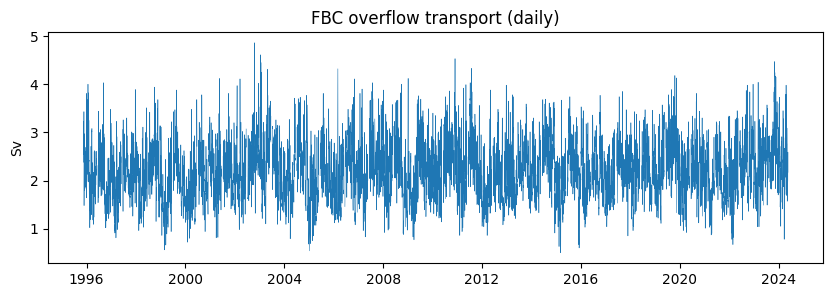

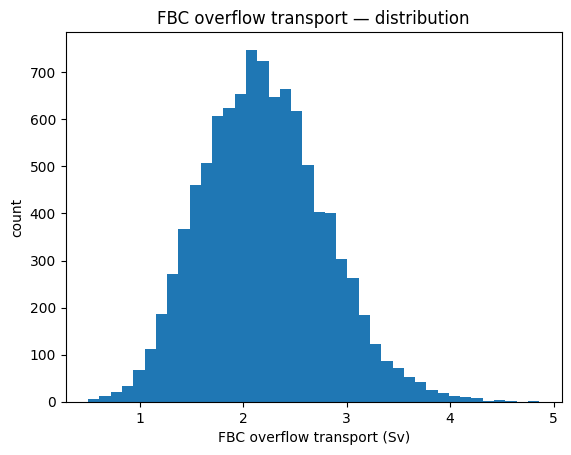

In [12]:
import matplotlib.pyplot as plt
from spectra_filtering import summary_stats   # the function from checkpoint 1

stats = summary_stats(values)
for k, v in stats.items():
    print(f"{k:>10}: {v}")

# raw series
plt.figure(figsize=(10, 3))
plt.plot(time, values, lw=0.4)
plt.ylabel("Sv"); plt.title("FBC overflow transport (daily)"); plt.show()

# distribution
plt.figure()
plt.hist(values[np.isfinite(values)], bins=40)
plt.xlabel("FBC overflow transport (Sv)"); plt.ylabel("count")
plt.title("FBC overflow transport — distribution"); plt.show()

In [13]:
import numpy as np
isnan = np.isnan(values)
# lengths of consecutive-NaN runs
runs = np.diff(np.flatnonzero(np.concatenate(([True], np.diff(isnan)!=0, [True]))))[isnan[np.flatnonzero(np.concatenate(([True], np.diff(isnan)!=0)))] ]
gap_runs = [int(r) for r in runs]
print("number of separate gaps:", len(gap_runs))
print("longest gap (days):", max(gap_runs))
print("gaps longer than 7 days:", sum(g > 7 for g in gap_runs))

number of separate gaps: 28
longest gap (days): 28
gaps longer than 7 days: 26


NaN after fill: 0
Parseval ratio (Welch, raw): 0.964   # ~1 is good


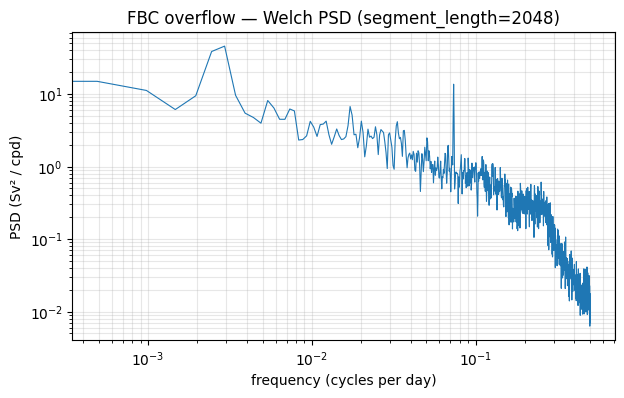

In [14]:
from spectra_filtering import fill_gaps, tukey_lowpass, welch_psd, parseval_ratio

# 1. gap-filled series (regular grid required for FFT/Welch)
filled = fill_gaps(values)
print("NaN after fill:", int(np.isnan(filled).sum()))   # expect 0

# 2. Welch spectrum of the raw (gap-filled) series
#    segment_length sets resolution + number of segments (smoothness/d.o.f.)
seg = 2048                      # ~5.6 yr per segment on a daily grid; we can tune this
f_raw, P_raw = welch_psd(filled, dt_days, segment_length=seg, overlap=0.5)

# 3. Parseval sanity check on the REAL data
ratio = parseval_ratio(filled - filled.mean(), f_raw, P_raw)
print(f"Parseval ratio (Welch, raw): {ratio:.3f}   # ~1 is good")

# 4. quick look at the spectrum
plt.figure(figsize=(7,4))
plt.loglog(f_raw, P_raw, lw=0.8)
plt.xlabel("frequency (cycles per day)")
plt.ylabel("PSD (Sv² / cpd)")
plt.title(f"FBC overflow — Welch PSD (segment_length={seg})")
plt.grid(True, which="both", alpha=0.3)
plt.show()

seg= 2048  ~5.6 yr/seg  ~9 segments  lowest f = 4.88e-04 cpd
seg= 1024  ~2.8 yr/seg  ~19 segments  lowest f = 9.77e-04 cpd
seg=  512  ~1.4 yr/seg  ~39 segments  lowest f = 1.95e-03 cpd


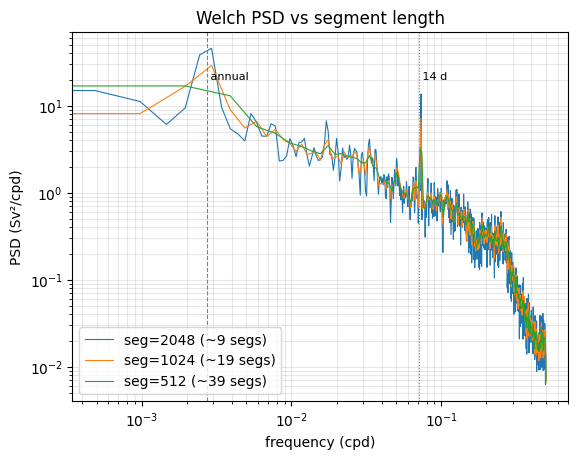

In [15]:
for seg in (2048, 1024, 512):
    f, P = welch_psd(filled, dt_days, segment_length=seg, overlap=0.5)
    n_seg = int((len(filled) - seg) / (seg*0.5)) + 1
    print(f"seg={seg:5d}  ~{seg*dt_days/365:.1f} yr/seg  ~{n_seg} segments  "
          f"lowest f = {1/(seg*dt_days):.2e} cpd")
    plt.loglog(f, P, lw=0.8, label=f"seg={seg} (~{n_seg} segs)")
plt.axvline(1/365, ls="--", c="grey", lw=0.8); plt.text(1/365, 2e1, " annual", fontsize=8)
plt.axvline(1/14,  ls=":",  c="grey", lw=0.8); plt.text(1/14, 2e1, " 14 d", fontsize=8)
plt.xlabel("frequency (cpd)"); plt.ylabel("PSD (Sv²/cpd)")
plt.legend(); plt.grid(True, which="both", alpha=0.3); plt.title("Welch PSD vs segment length"); plt.show()

In [18]:
import os
print("kernel cwd:", os.getcwd())
print("figures/ here?", os.path.isdir("figures"))

kernel cwd: /Users/mac/Downloads/assignment/notebooks
figures/ here? False


saving figures to: /Users/mac/Downloads/assignment/figures


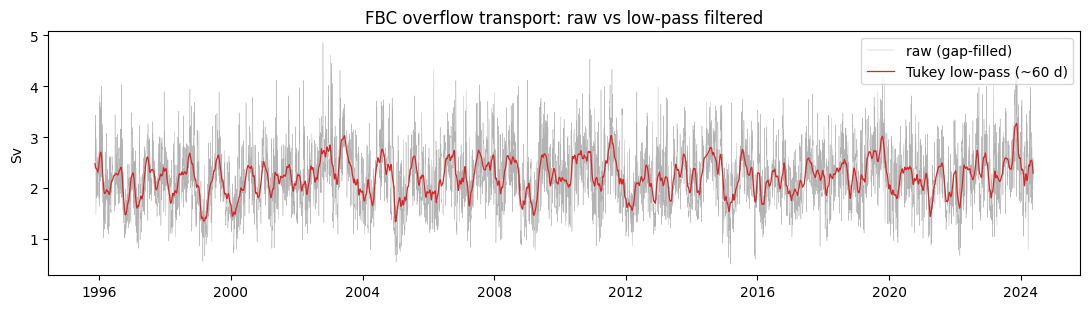

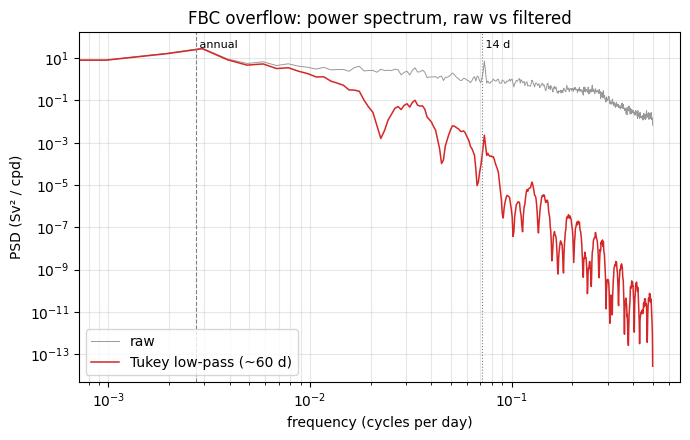

In [19]:
FIG_DIR = root / "figures"
FIG_DIR.mkdir(exist_ok=True)
print("saving figures to:", FIG_DIR)

SEG = 1024
WIN = 60     # Tukey window length in samples = ~60 days → low-pass, keeps ≳2-month variability

# filtered series (the provided Tukey low-pass)
filt = tukey_lowpass(filled, WIN)

# spectra of raw vs filtered, same settings
f_raw,  P_raw  = welch_psd(filled, dt_days, segment_length=SEG, overlap=0.5)
f_filt, P_filt = welch_psd(filt,   dt_days, segment_length=SEG, overlap=0.5)

# ---- Figure 1: filtered series over raw (time domain) ----
fig1, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(time, filled, lw=0.3, color="0.7", label="raw (gap-filled)")
ax.plot(time, filt,   lw=0.9, color="C3",  label=f"Tukey low-pass (~{WIN} d)")
ax.set_ylabel("Sv"); ax.set_title("FBC overflow transport: raw vs low-pass filtered")
ax.legend(loc="upper right"); fig1.tight_layout()
fig1.savefig(FIG_DIR / "fig1_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Figure 2: spectra of raw vs filtered (log–log) ----
fig2, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(f_raw,  P_raw,  lw=0.7, color="0.6", label="raw")
ax.loglog(f_filt, P_filt, lw=1.1, color="C3",  label=f"Tukey low-pass (~{WIN} d)")
ax.axvline(1/365, ls="--", c="grey", lw=0.8); ax.text(1/365, P_raw.max(), " annual", fontsize=8)
ax.axvline(1/14,  ls=":",  c="grey", lw=0.8); ax.text(1/14,  P_raw.max(), " 14 d",  fontsize=8)
ax.set_xlabel("frequency (cycles per day)"); ax.set_ylabel("PSD (Sv² / cpd)")
ax.set_title("FBC overflow: power spectrum, raw vs filtered")
ax.legend(); ax.grid(True, which="both", alpha=0.3); fig2.tight_layout()
fig2.savefig(FIG_DIR / "fig2_spectra.png", dpi=150, bbox_inches="tight")
plt.show()